## **Agent Tool Selection Strategies — Part 2 of 5**
#### **Understanding Exploration vs. Exploitation in Production AI Systems**

> **Author:** Isaac Cobena Appiah</br> 
> **Date:** January, 2026</br> 
> **Type:** Medium/Substack/Website (talkcodetome.com) Tutorial

*Why tool selection is the hardest decision an agent makes — set up as a multi-armed bandit, with a synthetic environment and a hard look at signal vs. noise.*

### **The Four Strategies**

*Greedy, Random, Epsilon-Greedy and UCB — implemented from scratch, then run side-by-side on the 9-trial comparison grid and 50-run learning curves.*

> **Series:** Part 1 · Part 2 · Part 3 · Part 4 · Part 5  —  *you are reading Part 2.*

**Previously:** In Part 1 we framed tool selection as a bandit problem and built a synthetic environment where the optimal tool for each task is known but hidden from the agent.

Run the foundation cell below first — it re-establishes the shared tools, tasks, environment and agents from the earlier parts so this notebook runs on its own.

In [1]:
# ============================================================
#  FOUNDATION  (carried over from earlier parts)
#  Run this cell first, then continue down the notebook.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from collections import defaultdict, Counter
import warnings

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

N_TASKS        = 200     # Tasks per simulation run
N_TRIALS       = 9       # Repeated trials per strategy (for 3×3 grid)
N_AVG_TRIALS   = 50      # Trials for averaged learning curves
N_STRATEGIES   = 4       # Greedy, Random, Epsilon-Greedy, UCB

TOOLS = {
    'search_faq':       'Search FAQ database (fast, focused)',
    'query_database':   'Retrieve customer records (accurate, specific)',
    'web_search':       'Search external web (broad, noisy)',
    'calculator':       'Perform calculations (deterministic)',
    'email_api':        'Escalate to human support',
}
TOOL_NAMES = list(TOOLS.keys())
N_TOOLS    = len(TOOL_NAMES)

TASK_TYPES = {
    'order_status':    {'optimal_tool': 'query_database', 'base_success': 0.95},
    'password_reset':  {'optimal_tool': 'search_faq',     'base_success': 0.90},
    'calculation':     {'optimal_tool': 'calculator',     'base_success': 1.00},
    'return_policy':   {'optimal_tool': 'web_search',     'base_success': 0.75},
    'complex_issue':   {'optimal_tool': 'email_api',      'base_success': 0.82},
}
TASK_NAMES = list(TASK_TYPES.keys())
N_TASKS_T  = len(TASK_NAMES)

PALETTE = {
    'greedy':      '#e74c3c',    # Red    — greedy (high bias)
    'random':      '#9b59b6',    # Purple — random (high variance)
    'epsilon':     '#27ae60',    # Green  — epsilon-greedy (balanced)
    'ucb':         '#2980b9',    # Blue   — UCB (intelligent)
    'optimal':     '#2c3e50',    # Dark   — optimal signal line
    'noise':       '#95a5a6',    # Grey   — noise / background
    'highlight':   '#f39c12',    # Amber  — emphasis
    'background':  '#f8f9fa',    # Light  — panel backgrounds
    'reward':      '#1abc9c',    # Teal   — reward/success signal
}

STRATEGY_COLORS = {
    'Greedy':           PALETTE['greedy'],
    'Random':           PALETTE['random'],
    'Epsilon-Greedy':   PALETTE['epsilon'],
    'UCB':              PALETTE['ucb'],
}

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 110, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'font.size': 9, 'lines.linewidth': 2.2,
})

print(f"Random state  : {RANDOM_STATE}")
print(f"Tasks / run   : {N_TASKS}")
print(f"Trials        : {N_TRIALS} per strategy (grid) | {N_AVG_TRIALS} (learning curves)")
print(f"Tools         : {N_TOOLS} — {TOOL_NAMES}")
print(f"Task types    : {N_TASKS_T} — {TASK_NAMES}")
print()
print("Ground Truth Environment (Hidden from the Agent):")
print(f"{'Task':<20} {'Optimal Tool':<20} {'Base Success'}")
print(" ")
for task, info in TASK_TYPES.items():
    print(f"{task:<20} {info['optimal_tool']:<20} {info['base_success']:.0%}")

class AgentEnvironment:
    """
    Synthetic environment for studying AI agent tool selection.
    
    The environment is responsible for three things:
    
    1. Generating incoming user tasks.
    2. Evaluating the tool selected by the agent.
    3. Returning a reward that indicates whether the tool succeeded.
    
    The agent never observes the true success probabilities or the
    optimal tool for any task. It must discover those relationships
    through trial and error.
    
    This closely resembles production agent systems, where only the
    outcome of an action—not the underlying ground truth—is visible.
    """
    def __init__(self, noise_level=0.15, seed=None):
        """
        Parameters
        ----------
        noise_level : float
            Controls how often even the optimal tool fails (environment stochasticity).
            noise_level=0   → deterministic environment (only optimal tool succeeds)
            noise_level=0.3 → chaotic environment (tools fail randomly)
        seed : int
            Random seed for reproducibility.
        """
        self.noise_level = noise_level
        self.rng = np.random.default_rng(seed)
        self.task_history = []
        self.reward_history = []
        self.step_count = 0

    def generate_task(self):
        """
        Sample the next incoming task.
        
        Each task represents a user request that the agent must solve
        by selecting one of the available tools.
        """
        task_type = self.rng.choice(TASK_NAMES)
        self.step_count += 1
        return task_type

    def execute_tool(self, task_type, tool_name):
        """
        Execute the selected tool for a given task.
        
        The environment compares the chosen tool with the hidden
        optimal tool for that task and generates a stochastic reward.
        
        Optimal tools succeed most of the time, although random noise
        allows occasional failures.
        
        Non-optimal tools usually fail but may occasionally succeed by
        chance.
        
        Returns
        -------
        reward : int
            1 if the tool succeeds, otherwise 0.
        """
        optimal    = TASK_TYPES[task_type]['optimal_tool']
        base_rate  = TASK_TYPES[task_type]['base_success']
        noise      = self.rng.uniform(0, self.noise_level)

        if tool_name == optimal:
            success_prob = base_rate - noise       # HIGH probability
        else:
            success_prob = noise * 0.4             # LOW probability (mostly fail)

        reward = 1 if self.rng.random() < success_prob else 0
        self.task_history.append(task_type)
        self.reward_history.append(reward)
        return reward

    def reset(self):
        """
        Reset the environment before starting a new simulation.
        
        This clears the interaction history while leaving the underlying
        task-to-tool relationships unchanged.
        """
        self.task_history = []
        self.reward_history = []
        self.step_count = 0

    def get_oracle_rate(self):
        """
        Return the expected success rate of an ideal agent.
        
        The oracle always selects the optimal tool for every task and
        therefore represents the upper performance limit.
        """
        return np.mean([TASK_TYPES[t]['base_success'] for t in TASK_NAMES])


# Test the environment
env_test = AgentEnvironment(noise_level=0.15, seed=RANDOM_STATE)

print("Environment Test:")
print(f"Oracle (optimal) rate: {env_test.get_oracle_rate():.3f}")
print()
print("Simulating 50 tasks with optimal tool selection:")
rewards = []
for _ in range(50):
    task = env_test.generate_task()
    optimal = TASK_TYPES[task]['optimal_tool']
    r = env_test.execute_tool(task, optimal)
    rewards.append(r)
print(f"Observed success rate (optimal): {np.mean(rewards):.3f}")
print()
print("Simulating 50 tasks with worst tool (web_search for everything):")
env_test.reset()
rewards_worst = []
for _ in range(50):
    task = env_test.generate_task()
    r = env_test.execute_tool(task, 'web_search')
    rewards_worst.append(r)
print(f"Observed success rate (web_search only): {np.mean(rewards_worst):.3f}")
print()
print("Gap between optimal and naive strategy: "
      f"{np.mean(rewards) - np.mean(rewards_worst):.3f} — this is what good tool selection recovers")

class GreedyAgent:
    """
    High Bias / Low Variance — Exploitation Only.

    Strategy: Always select the tool with the highest observed success rate.
    If no tool has been tried, select randomly (cold start).

    Bias-variance analogy: Linear regression on nonlinear data.
    → Stable, predictable, consistently suboptimal.

    Production failure mode: Gets stuck on first-working tool,
    misses better tools discovered later.
    """

    def __init__(self, n_tools=N_TOOLS):
        self.name     = 'Greedy'
        self.color    = PALETTE['greedy']
        self.successes = np.zeros(n_tools)
        self.attempts  = np.zeros(n_tools)
        self.rng       = np.random.default_rng(RANDOM_STATE)

    def select_tool(self, task_type=None):
        # Cold start: if any tool untried, pick random untried tool first
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        # Otherwise: pure exploitation — pick highest-rate tool
        rates = self.successes / np.maximum(self.attempts, 1)
        return TOOL_NAMES[np.argmax(rates)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


class RandomAgent:
    """
    Low Bias / High Variance — Exploration Only.

    Strategy: Select tools uniformly at random, ignoring all history.

    Bias-variance analogy: Degree-12 polynomial regression.
    → Discovers optimal tools eventually, but performance is wildly unstable.
    → Wastes money on known-bad tools even after learning.

    Production failure mode: Inconsistent user experience,
    high API costs from redundant failed tool calls.
    """

    def __init__(self):
        self.name  = 'Random'
        self.color = PALETTE['random']
        self.rng   = np.random.default_rng(RANDOM_STATE + 1)

    def select_tool(self, task_type=None):
        return self.rng.choice(TOOL_NAMES)

    def update(self, tool_name, reward):
        pass   # Random agent ignores feedback — this is the key failure

    def reset(self):
        pass

    def get_estimates(self):
        return np.ones(N_TOOLS) / N_TOOLS   # Uniform — no belief


class EpsilonGreedyAgent:
    """
    Balanced Trade-off — Controlled Exploration.

    Strategy: With probability epsilon, explore (random tool).
               With probability 1-epsilon, exploit (best-known tool).

    Bias-variance analogy: Degree 3-5 polynomial — the sweet spot.
    → Mostly exploits, occasionally learns. Converges to near-optimal.

    The epsilon parameter controls the trade-off:
        epsilon=0   → Greedy (high bias)
        epsilon=1   → Random (high variance)
        epsilon=0.1 → Sweet spot for most production agents

    Production use: Most recommended strategy for customer-facing agents.
    """

    def __init__(self, epsilon=0.1):
        self.name      = f'Epsilon-Greedy'
        self.epsilon   = epsilon
        self.color     = PALETTE['epsilon']
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.rng       = np.random.default_rng(RANDOM_STATE + 2)

    def select_tool(self, task_type=None):
        if self.rng.random() < self.epsilon:
            return self.rng.choice(TOOL_NAMES)   # Explore
        # Exploit: pick best known, break ties randomly
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        rates = self.successes / np.maximum(self.attempts, 1)
        return TOOL_NAMES[np.argmax(rates)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


class UCBAgent:
    """
    Upper Confidence Bound — Intelligent Exploration.

    Strategy: Select the tool maximizing Q(a) + c * sqrt(ln(t) / N(a))
        Q(a)  = estimated success rate of tool a
        t     = total steps so far
        N(a)  = times tool a has been tried
        c     = exploration coefficient (confidence level)

    Why UCB is principled:
    → The bonus term is LARGE when N(a) is small (unexplored → explore)
    → The bonus term SHRINKS as N(a) grows (well-understood → exploit)
    → Automatically balances exploration based on uncertainty

    Bias-variance analogy: Regularized regression — penalizes overconfidence,
    encourages principled exploration of uncertain tools.

    Production use: High-stakes systems where missed opportunities are costly
    (e.g., medical triage agents, financial routing agents).
    """

    def __init__(self, c=1.5):
        self.name     = 'UCB'
        self.c        = c    # Exploration coefficient
        self.color    = PALETTE['ucb']
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.t        = 0
        self.rng      = np.random.default_rng(RANDOM_STATE + 3)

    def select_tool(self, task_type=None):
        self.t += 1
        # Explore any untried tool first
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        # UCB score: estimated value + exploration bonus
        q_values = self.successes / np.maximum(self.attempts, 1)
        bonus    = self.c * np.sqrt(np.log(self.t) / np.maximum(self.attempts, 1))
        ucb_scores = q_values + bonus
        return TOOL_NAMES[np.argmax(ucb_scores)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.t = 0

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


# Core simulation function 
def run_simulation(agent, n_tasks=N_TASKS, noise_level=0.15, seed=None):
    """
    Run a single episode: agent interacts with environment for n_tasks steps.

    Returns: success_history (list of 0/1), tool_history (list of tool names)
    """
    env = AgentEnvironment(noise_level=noise_level, seed=seed)
    agent.reset()
    success_history = []
    tool_history    = []

    for _ in range(n_tasks):
        task       = env.generate_task()
        tool       = agent.select_tool(task)
        reward     = env.execute_tool(task, tool)
        agent.update(tool, reward)
        success_history.append(reward)
        tool_history.append(tool)

    return success_history, tool_history

# Quick validation
print("Agent Validation (single 200-task run):")
print(f"{'Agent':<25} {'Final Success Rate':>20} {'Std (50 runs)':>15}")
print(" " + "-"*62)
agents_test = [GreedyAgent(), RandomAgent(), EpsilonGreedyAgent(0.1), UCBAgent()]
for agent in agents_test:
    rates = []
    for trial in range(50):
        hist, _ = run_simulation(agent, n_tasks=200, seed=RANDOM_STATE + trial * 7)
        rates.append(np.mean(hist[-50:]))   # Last 50 tasks (converged performance)
    print(f"{agent.name:<25} {np.mean(rates):>20.4f} {np.std(rates):>15.4f}")


# ---- Strategy registry (carried over) ----
agent_configs = [
    ('Greedy',         GreedyAgent,                     PALETTE['greedy']),
    ('Random',         RandomAgent,                     PALETTE['random']),
    ('Epsilon-Greedy', lambda: EpsilonGreedyAgent(0.1), PALETTE['epsilon']),
    ('UCB',            lambda: UCBAgent(c=1.5),         PALETTE['ucb']),
]
print('Foundation ready: tools, tasks, environment, agents, run_simulation, agent_configs')

Random state  : 42
Tasks / run   : 200
Trials        : 9 per strategy (grid) | 50 (learning curves)
Tools         : 5 — ['search_faq', 'query_database', 'web_search', 'calculator', 'email_api']
Task types    : 5 — ['order_status', 'password_reset', 'calculation', 'return_policy', 'complex_issue']

Ground Truth Environment (Hidden from the Agent):
Task                 Optimal Tool         Base Success
 
order_status         query_database       95%
password_reset       search_faq           90%
calculation          calculator           100%
return_policy        web_search           75%
complex_issue        email_api            82%
Environment Test:
Oracle (optimal) rate: 0.884

Simulating 50 tasks with optimal tool selection:
Observed success rate (optimal): 0.840

Simulating 50 tasks with worst tool (web_search for everything):
Observed success rate (web_search only): 0.140

Gap between optimal and naive strategy: 0.700 — this is what good tool selection recovers
Agent Validation (singl

### **AGENT CLASSES**
#### **Greedy Agent — High Bias, Low Variance**
**Exploitation-Only Strategy**

The greedy agent always selects the tool with the highest observed success rate so far. It never explores alternatives once it forms an early belief.

This makes it extremely simple — but also fragile.

**Why this leads to high bias::**
With limited early experience, the agent can lock onto a suboptimal tool. If `web_search` performs well on the first few tasks, the agent may overcommit to it even when better tools exist for other contexts. For example, it may chose/commit to `web_search` indefinitely — even when it consistently performs poorly for tasks like `order_status`.

**Why variance is low:**
Given similar early experiences, the agent behaves almost identically across runs. It is stable, predictable, and consistently wrong when its early assumption is wrong. Not adaptive.

> The greedy agent is like a linear model trying to fit nonlinear reality. It fixes a single interpretation of the world and never revises it. The result is consistent behavior — and consistently suboptimal decisions. No uncertainty modeling, no exploration, no recovery.

#### **Agent Implementations**

We now define four agent types with increasing levels of exploration. Each represents a different position on the exploration – exploitation spectrum, from purely greedy to fully uncertainty-aware strategies.

In [2]:
class GreedyAgent:
    """
    High Bias / Low Variance — Exploitation Only.

    Strategy: Always select the tool with the highest observed success rate.
    If no tool has been tried, select randomly (cold start).

    Bias-variance analogy: Linear regression on nonlinear data.
    → Stable, predictable, consistently suboptimal.

    Production failure mode: Gets stuck on first-working tool,
    misses better tools discovered later.
    """

    def __init__(self, n_tools=N_TOOLS):
        self.name     = 'Greedy'
        self.color    = PALETTE['greedy']
        self.successes = np.zeros(n_tools)
        self.attempts  = np.zeros(n_tools)
        self.rng       = np.random.default_rng(RANDOM_STATE)

    def select_tool(self, task_type=None):
        # Cold start: if any tool untried, pick random untried tool first
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        # Otherwise: pure exploitation — pick highest-rate tool
        rates = self.successes / np.maximum(self.attempts, 1)
        return TOOL_NAMES[np.argmax(rates)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


class RandomAgent:
    """
    Low Bias / High Variance — Exploration Only.

    Strategy: Select tools uniformly at random, ignoring all history.

    Bias-variance analogy: Degree-12 polynomial regression.
    → Discovers optimal tools eventually, but performance is wildly unstable.
    → Wastes money on known-bad tools even after learning.

    Production failure mode: Inconsistent user experience,
    high API costs from redundant failed tool calls.
    """

    def __init__(self):
        self.name  = 'Random'
        self.color = PALETTE['random']
        self.rng   = np.random.default_rng(RANDOM_STATE + 1)

    def select_tool(self, task_type=None):
        return self.rng.choice(TOOL_NAMES)

    def update(self, tool_name, reward):
        pass   # Random agent ignores feedback — this is the key failure

    def reset(self):
        pass

    def get_estimates(self):
        return np.ones(N_TOOLS) / N_TOOLS   # Uniform — no belief


class EpsilonGreedyAgent:
    """
    Balanced Trade-off — Controlled Exploration.

    Strategy: With probability epsilon, explore (random tool).
               With probability 1-epsilon, exploit (best-known tool).

    Bias-variance analogy: Degree 3-5 polynomial — the sweet spot.
    → Mostly exploits, occasionally learns. Converges to near-optimal.

    The epsilon parameter controls the trade-off:
        epsilon=0   → Greedy (high bias)
        epsilon=1   → Random (high variance)
        epsilon=0.1 → Sweet spot for most production agents

    Production use: Most recommended strategy for customer-facing agents.
    """

    def __init__(self, epsilon=0.1):
        self.name      = f'Epsilon-Greedy'
        self.epsilon   = epsilon
        self.color     = PALETTE['epsilon']
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.rng       = np.random.default_rng(RANDOM_STATE + 2)

    def select_tool(self, task_type=None):
        if self.rng.random() < self.epsilon:
            return self.rng.choice(TOOL_NAMES)   # Explore
        # Exploit: pick best known, break ties randomly
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        rates = self.successes / np.maximum(self.attempts, 1)
        return TOOL_NAMES[np.argmax(rates)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


class UCBAgent:
    """
    Upper Confidence Bound — Intelligent Exploration.

    Strategy: Select the tool maximizing Q(a) + c * sqrt(ln(t) / N(a))
        Q(a)  = estimated success rate of tool a
        t     = total steps so far
        N(a)  = times tool a has been tried
        c     = exploration coefficient (confidence level)

    Why UCB is principled:
    → The bonus term is LARGE when N(a) is small (unexplored → explore)
    → The bonus term SHRINKS as N(a) grows (well-understood → exploit)
    → Automatically balances exploration based on uncertainty

    Bias-variance analogy: Regularized regression — penalizes overconfidence,
    encourages principled exploration of uncertain tools.

    Production use: High-stakes systems where missed opportunities are costly
    (e.g., medical triage agents, financial routing agents).
    """

    def __init__(self, c=1.5):
        self.name     = 'UCB'
        self.c        = c    # Exploration coefficient
        self.color    = PALETTE['ucb']
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.t        = 0
        self.rng      = np.random.default_rng(RANDOM_STATE + 3)

    def select_tool(self, task_type=None):
        self.t += 1
        # Explore any untried tool first
        untried = np.where(self.attempts == 0)[0]
        if len(untried) > 0:
            return TOOL_NAMES[self.rng.choice(untried)]
        # UCB score: estimated value + exploration bonus
        q_values = self.successes / np.maximum(self.attempts, 1)
        bonus    = self.c * np.sqrt(np.log(self.t) / np.maximum(self.attempts, 1))
        ucb_scores = q_values + bonus
        return TOOL_NAMES[np.argmax(ucb_scores)]

    def update(self, tool_name, reward):
        idx = TOOL_NAMES.index(tool_name)
        self.attempts[idx]  += 1
        self.successes[idx] += reward

    def reset(self):
        self.successes = np.zeros(N_TOOLS)
        self.attempts  = np.zeros(N_TOOLS)
        self.t = 0

    def get_estimates(self):
        return self.successes / np.maximum(self.attempts, 1)


# Core simulation function 
def run_simulation(agent, n_tasks=N_TASKS, noise_level=0.15, seed=None):
    """
    Run a single episode: agent interacts with environment for n_tasks steps.

    Returns: success_history (list of 0/1), tool_history (list of tool names)
    """
    env = AgentEnvironment(noise_level=noise_level, seed=seed)
    agent.reset()
    success_history = []
    tool_history    = []

    for _ in range(n_tasks):
        task       = env.generate_task()
        tool       = agent.select_tool(task)
        reward     = env.execute_tool(task, tool)
        agent.update(tool, reward)
        success_history.append(reward)
        tool_history.append(tool)

    return success_history, tool_history

# Quick validation
print("Agent Validation (single 200-task run):")
print(f"{'Agent':<25} {'Final Success Rate':>20} {'Std (50 runs)':>15}")
print(" " + "-"*62)
agents_test = [GreedyAgent(), RandomAgent(), EpsilonGreedyAgent(0.1), UCBAgent()]
for agent in agents_test:
    rates = []
    for trial in range(50):
        hist, _ = run_simulation(agent, n_tasks=200, seed=RANDOM_STATE + trial * 7)
        rates.append(np.mean(hist[-50:]))   # Last 50 tasks (converged performance)
    print(f"{agent.name:<25} {np.mean(rates):>20.4f} {np.std(rates):>15.4f}")

Agent Validation (single 200-task run):
Agent                       Final Success Rate   Std (50 runs)
 --------------------------------------------------------------
Greedy                                  0.1948          0.0670
Random                                  0.1820          0.0505
Epsilon-Greedy                          0.1876          0.0646
UCB                                     0.1892          0.0634


### **The 9-Trial Comparison Grid**
#### **The Bias–Variance Experiment Reproduced for Agents**

This is the central visualization of the tutorial. Each strategy is evaluated across 9 independent runs, where every run uses the same underlying tool-task structure but different noise realizations. This mirrors the classic 3×3 bias–variance grids used in statistical learning experiments.

**What to look for:**

* **Greedy:** Runs are highly consistent (low variance) but quickly plateau at a suboptimal level (high bias).
* **Random:** Runs vary widely (high variance) and fail to stabilize.
* **Epsilon-Greedy:** Moderate variability with steady convergence toward high performance.
* **UCB:** Tight convergence and strong final performance, reflecting efficient exploration.

> This grid *is* the exploration–exploitation trade-off in visual form. Each column shows variance across runs, while the plateau level reflects bias. The degree of convergence across trials reflects how well each strategy separates signal from noise.

We now move from final performance summaries to learning behavior itself. Instead of looking only at end results, we track how each agent’s performance evolves across tasks in 9 independent trials per strategy. This reveals not just what works, but how it learns or fails to learn over time.

Each subplot shows a rolling success rate (windowed average), compared against the oracle upper bound.

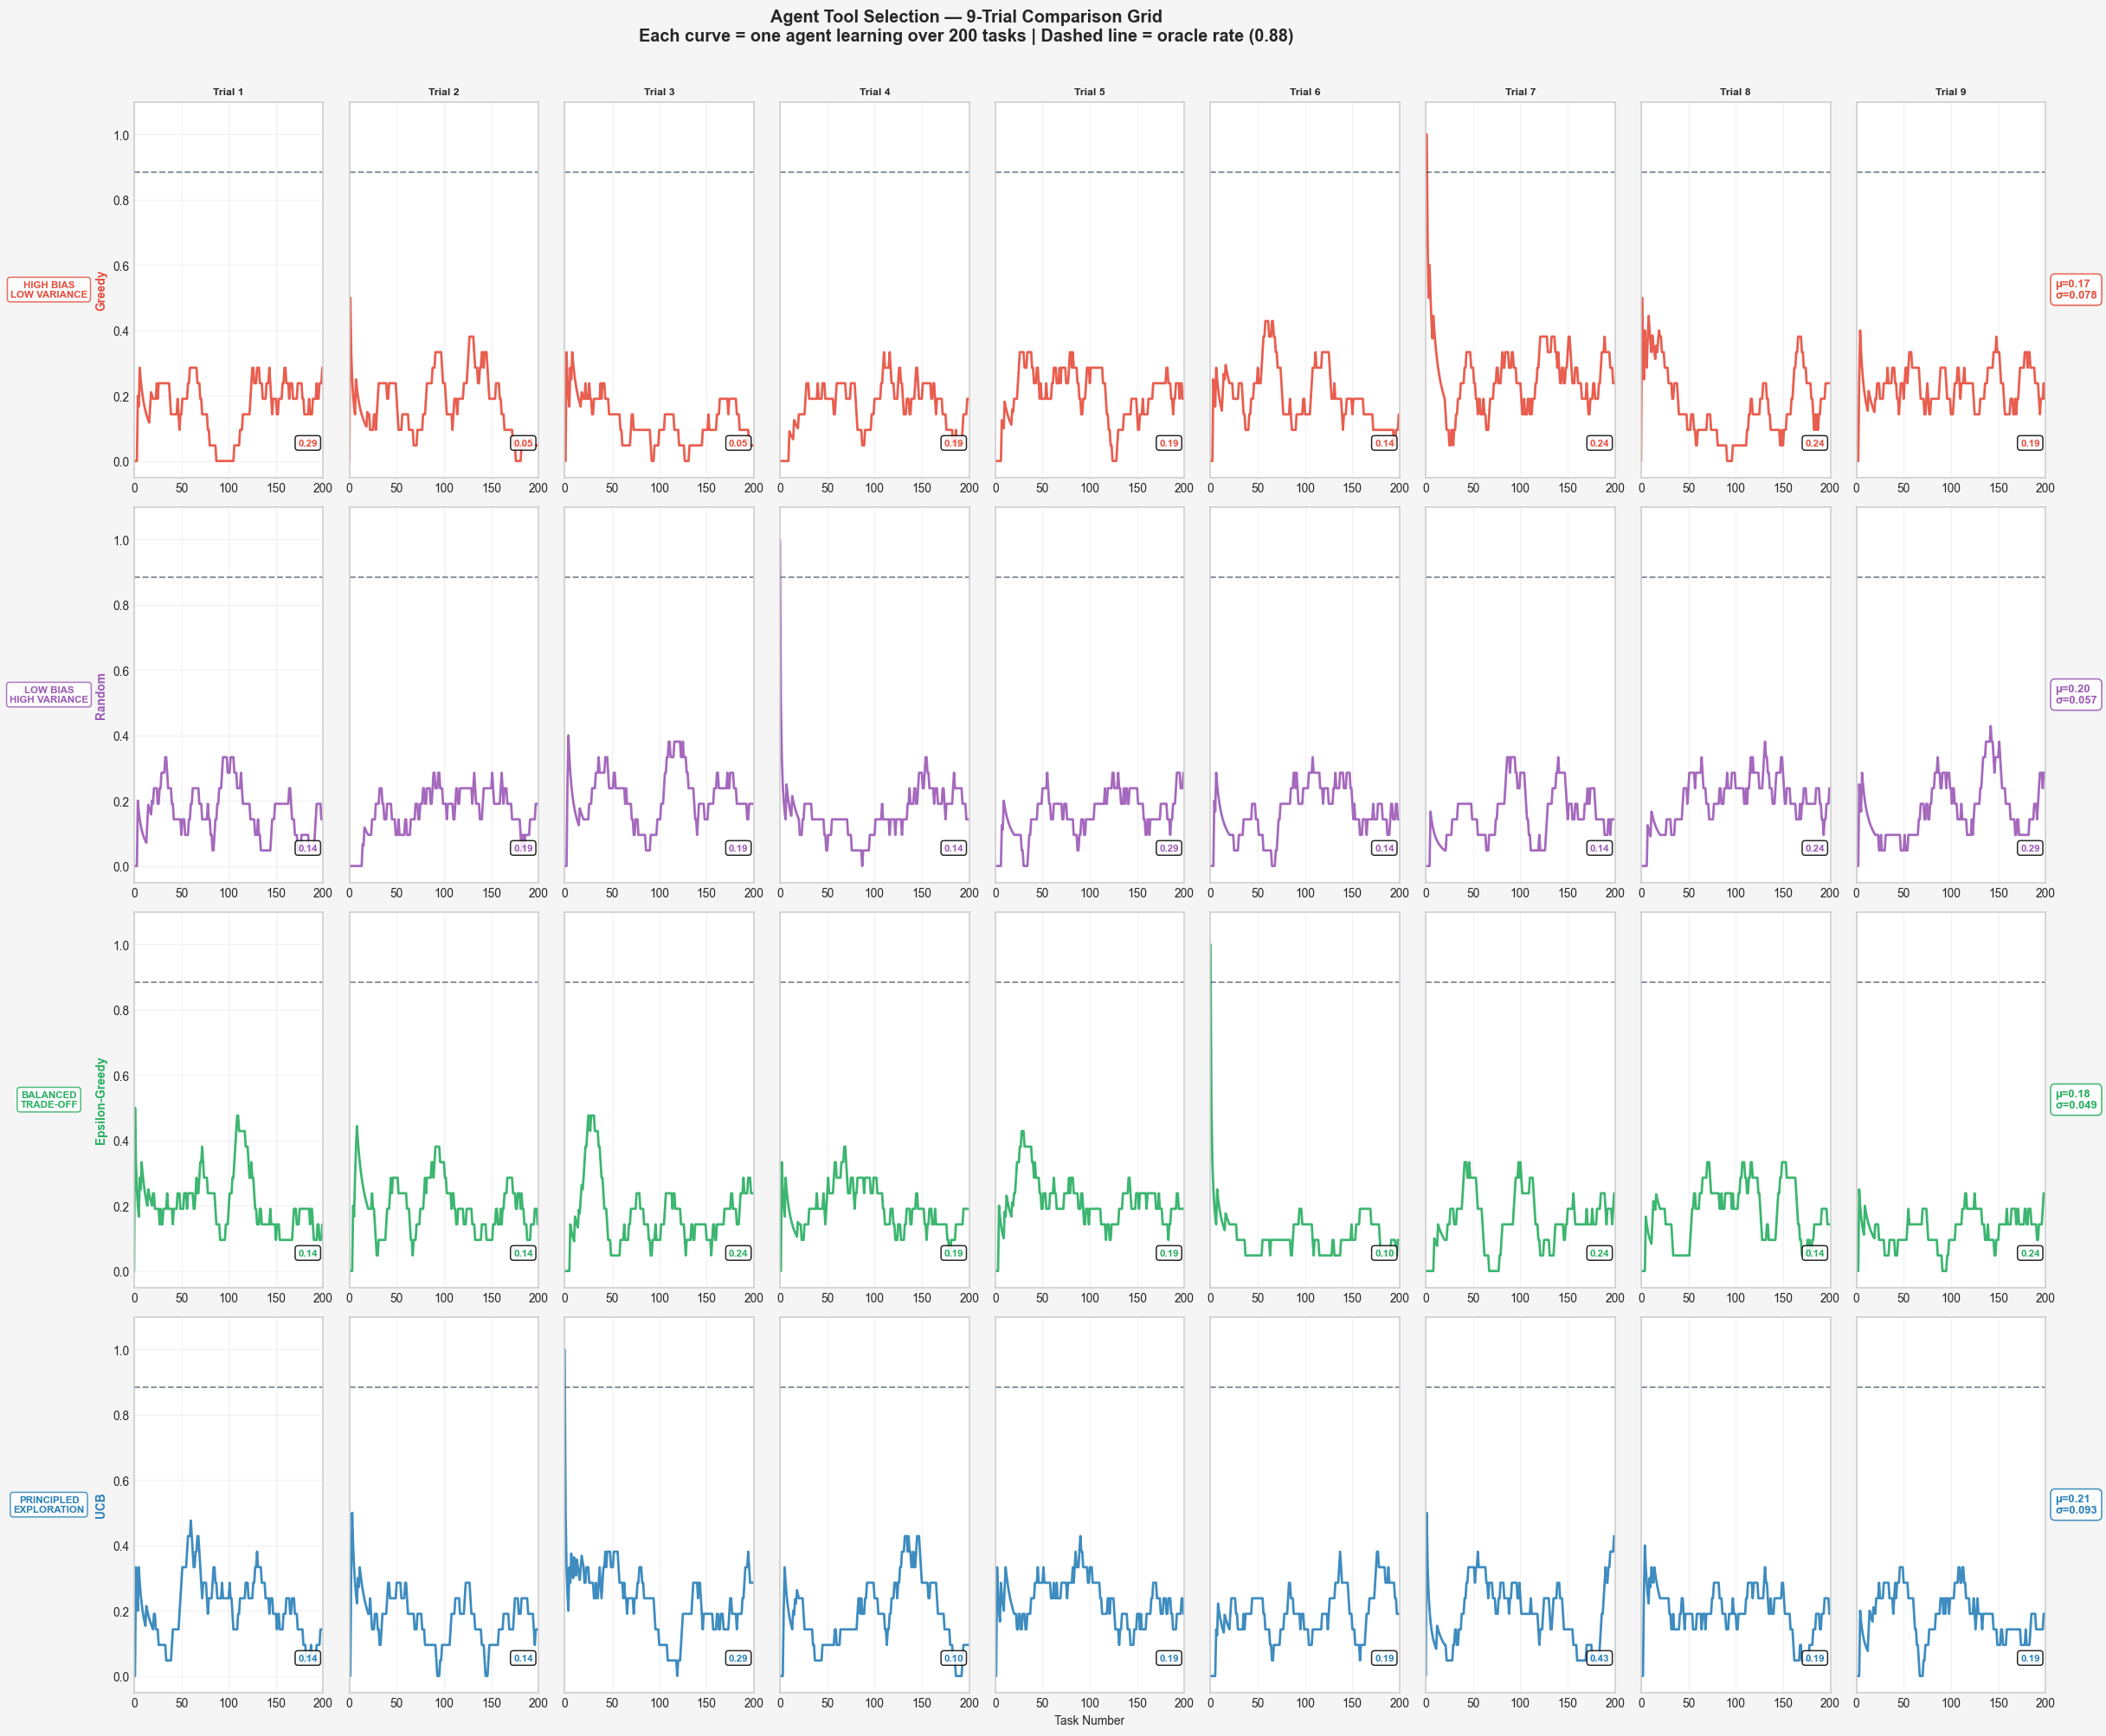

📊 9-Trial Final Performance Summary:
   Strategy               Mean Final Rate   Std (variance)    vs Oracle
   --------------------------------------------------------------------
   Greedy                          0.1746           0.0778      -0.7094
   Random                          0.1905           0.0898      -0.6935
   Epsilon-Greedy                  0.1534           0.0737      -0.7306
   UCB                             0.2011           0.0919      -0.6829


In [3]:
agent_configs = [
    ('Greedy',        GreedyAgent,                    PALETTE['greedy']),
    ('Random',        RandomAgent,                    PALETTE['random']),
    ('Epsilon-Greedy',lambda: EpsilonGreedyAgent(0.1),PALETTE['epsilon']),
    ('UCB',           lambda: UCBAgent(c=1.5),        PALETTE['ucb']),
]

fig, axes = plt.subplots(4, 9, figsize=(24, 18))
fig.patch.set_facecolor('#f5f5f5')

oracle_rate = AgentEnvironment().get_oracle_rate()

for row, (strategy_name, agent_class, color) in enumerate(agent_configs):
    final_rates = []
    for trial in range(N_TRIALS):
        ax = axes[row][trial]
        seed_t = RANDOM_STATE + row * 100 + trial * 13
        agent  = agent_class()
        hist, _ = run_simulation(agent, n_tasks=N_TASKS, seed=seed_t)

        # Rolling success rate (window=20)
        window = 20
        rolling = [np.mean(hist[max(0, i-window):i+1]) for i in range(len(hist))]
        final_rates.append(rolling[-1])

        ax.plot(rolling, color=color, lw=1.8, alpha=0.9)
        ax.axhline(oracle_rate, color=PALETTE['optimal'], ls='--', lw=1.2, alpha=0.6)
        ax.set_ylim(-0.05, 1.1)
        ax.set_xlim(0, N_TASKS)
        ax.grid(alpha=0.25)

        # Title only first row, label only last column
        if trial == 0:
            ax.set_ylabel(strategy_name, fontsize=9, fontweight='bold', color=color)
        else:
            ax.set_yticks([])
        if row == 0:
            ax.set_title(f'Trial {trial+1}', fontsize=8, fontweight='bold')
        if row == 3 and trial == 4:
            ax.set_xlabel('Task Number', fontsize=9)

        # Final rate annotation
        ax.text(0.97, 0.08, f'{rolling[-1]:.2f}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=7.5, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))

    # Row summary annotation
    mean_final = np.mean(final_rates)
    std_final  = np.std(final_rates)
    axes[row][8].text(1.05, 0.5,
                       f'μ={mean_final:.2f}\nσ={std_final:.3f}',
                       transform=axes[row][8].transAxes,
                       va='center', fontsize=8.5, color=color, fontweight='bold',
                       bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                                 edgecolor=color, alpha=0.9))

# Row labels on the left
row_labels = {
    0: 'HIGH BIAS\nLOW VARIANCE',
    1: 'LOW BIAS\nHIGH VARIANCE',
    2: 'BALANCED\nTRADE-OFF',
    3: 'PRINCIPLED\nEXPLORATION',
}
for row, (strategy_name, _, color) in enumerate(agent_configs):
    axes[row][0].annotate(row_labels[row],
                           xy=(-0.45, 0.5), xycoords='axes fraction',
                           va='center', ha='center', fontsize=7.5,
                           color=color, fontweight='bold',
                           bbox=dict(boxstyle='round', facecolor='white',
                                     edgecolor=color, alpha=0.8))

plt.suptitle('Agent Tool Selection — 9-Trial Comparison Grid\n'
             f'Each curve = one agent learning over {N_TASKS} tasks | '
             f'Dashed line = oracle rate ({oracle_rate:.2f})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0.08, 0, 1, 1])
plt.savefig('agent_03_nine_trial_grid.png', dpi=120, bbox_inches='tight')
plt.show()

print("📊 9-Trial Final Performance Summary:")
print(f"   {'Strategy':<20} {'Mean Final Rate':>17} {'Std (variance)':>16} {'vs Oracle':>12}")
print("   " + "-"*68)
for strategy_name, agent_class, color in agent_configs:
    finals = []
    for trial in range(N_TRIALS):
        agent = agent_class()
        hist, _ = run_simulation(agent, N_TASKS, seed=RANDOM_STATE+trial*13)
        window = 20
        rolling = [np.mean(hist[max(0,i-window):i+1]) for i in range(len(hist))]
        finals.append(rolling[-1])
    gap = np.mean(finals) - oracle_rate
    print(f"   {strategy_name:<20} {np.mean(finals):>17.4f} {np.std(finals):>16.4f} {gap:>+12.4f}")

This grid reveals the learning signatures of each strategy rather than just their final
### **Learning Curves — Stability and Convergence Across 50 Runs**
We now move from average learning behavior to *statistical stability*. Instead of looking at single trajectories, we examine 50 independent runs per strategy to measure both:

* **Expected performance (mean curve)**
* **Uncertainty across environments (variance bands)**
* **Final outcome stability (distribution of end performance)**

This allows us to distinguish strategies that are merely *good on average* from those that are *reliably good*.

Running 50 trials per strategy...
Greedy
Random
Epsilon-Greedy
UCB


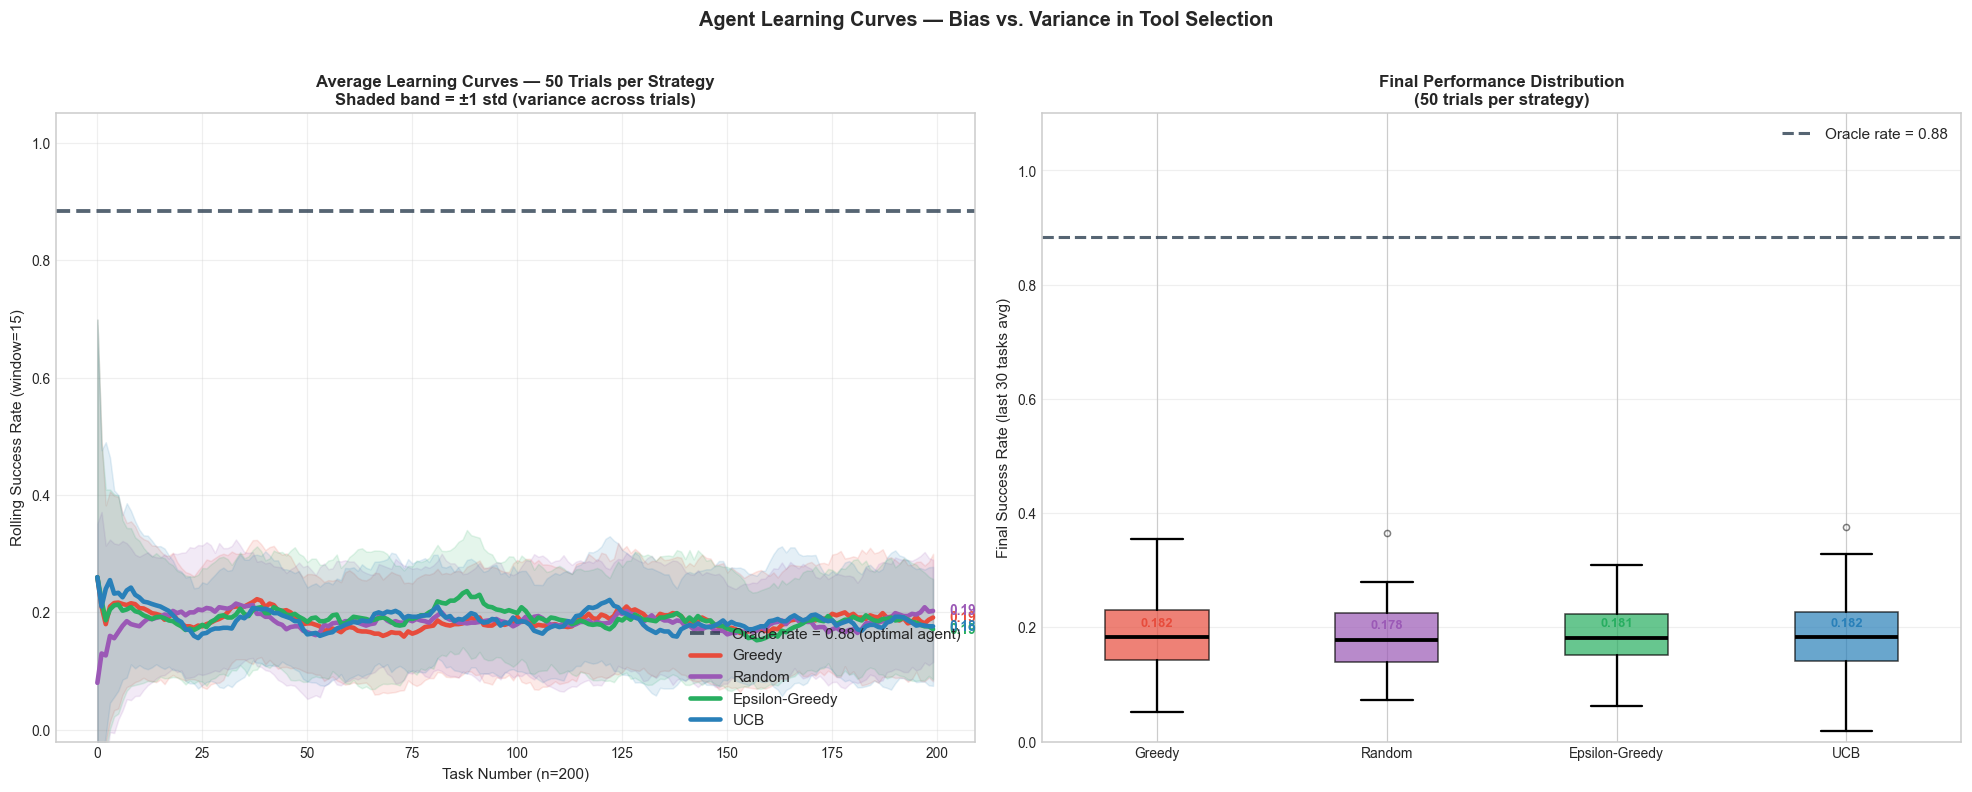


Final Performance Statistics (50 trials):
Strategy                 Mean      Std   Median    vs Oracle Regime
 ------------------------------------------------------------------------
Greedy                 0.1910   0.0685   0.1823      -0.6930  High Bias
Random                 0.1838   0.0626   0.1781      -0.7002  High Variance
Epsilon-Greedy         0.1860   0.0549   0.1812      -0.6980  Balanced
UCB                    0.1825   0.0685   0.1823      -0.7015  Optimal


In [4]:
fig, axes = plt.subplots(1, 2, figsize = (18, 7))
oracle_rate = AgentEnvironment().get_oracle_rate()
window = 15

print(f"Running {N_AVG_TRIALS} trials per strategy...")
all_curves = {}

for strategy_name, agent_class, color in agent_configs:
    curves = []
    for trial in range(N_AVG_TRIALS):
        agent  = agent_class()
        hist, _ = run_simulation(agent, N_TASKS, seed = RANDOM_STATE + trial * 17)
        rolling = [np.mean(hist[max(0,i-window):i+1]) for i in range(len(hist))]
        curves.append(rolling)
    all_curves[strategy_name] = np.array(curves)
    print(f"{strategy_name}")

# Left: Mean learning curves with variance bands 
ax1 = axes[0]
steps = np.arange(N_TASKS)

ax1.axhline(oracle_rate, color = PALETTE['optimal'], ls = '--', lw = 2.5, alpha = 0.8,
            label = f'Oracle rate = {oracle_rate:.2f} (optimal agent)')

for strategy_name, _, color in agent_configs:
    curves     = all_curves[strategy_name]
    mean_curve = curves.mean(axis=0)
    std_curve  = curves.std(axis=0)

    ax1.plot(steps, mean_curve, color=color, lw=3, label=f'{strategy_name}')
    ax1.fill_between(steps,
                      mean_curve - std_curve,
                      mean_curve + std_curve,
                      alpha = 0.12, color = color)

ax1.set_xlabel(f'Task Number (n={N_TASKS})')
ax1.set_ylabel('Rolling Success Rate (window=15)')
ax1.set_title(f'Average Learning Curves — {N_AVG_TRIALS} Trials per Strategy\n'
               'Shaded band = ±1 std (variance across trials)',
               fontweight = 'bold')
ax1.legend(fontsize = 10, loc = 'lower right')
ax1.grid(alpha = 0.3)
ax1.set_ylim(-0.02, 1.05)

# Annotate final convergence values
for strategy_name, _, color in agent_configs:
    final = all_curves[strategy_name][:, -20:].mean()
    ax1.annotate(f'{final:.2f}',
                  xy = (N_TASKS-1, all_curves[strategy_name].mean(axis = 0)[-1]),
                  xytext = (N_TASKS+3, all_curves[strategy_name].mean(axis = 0)[-1]),
                  fontsize = 9, color = color, fontweight = 'bold', va = 'center')

#  Right: Final performance distribution (boxplot) 
ax2 = axes[1]
final_perf = {name: all_curves[name][:, -30:].mean(axis=1)
              for name, _, _ in agent_configs}
names_order = [n for n, _, _ in agent_configs]
colors_order = [c for _, _, c in agent_configs]

bp = ax2.boxplot([final_perf[n] for n in names_order],
                  labels = names_order,
                  patch_artist = True,
                  medianprops = {'color': 'black', 'linewidth': 2.5},
                  whiskerprops = {'linewidth': 1.5},
                  capprops = {'linewidth': 1.5},
                  flierprops = {'marker': 'o', 'markersize': 4, 'alpha': 0.5})
for patch, color in zip(bp['boxes'], colors_order):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.axhline(oracle_rate, color = PALETTE['optimal'], ls = '--', lw = 2, alpha = 0.8,
            label = f'Oracle rate = {oracle_rate:.2f}')
ax2.set_ylabel('Final Success Rate (last 30 tasks avg)')
ax2.set_title(f'Final Performance Distribution\n({N_AVG_TRIALS} trials per strategy)',
               fontweight = 'bold')
ax2.legend(fontsize = 10)
ax2.grid(alpha = 0.3, axis = 'y')
ax2.set_ylim(0, 1.1)

for i, (name, _, color) in enumerate(agent_configs):
    median_val = np.median(final_perf[name])
    ax2.text(i+1, median_val + 0.02, f'{median_val:.3f}',
             ha = 'center', fontsize = 8.5, fontweight = 'bold', color = color)

plt.suptitle('Agent Learning Curves — Bias vs. Variance in Tool Selection',
             fontsize = 13, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.savefig('agent_04_learning_curves.png', dpi = 120, bbox_inches = 'tight')
plt.show()

print(f"\nFinal Performance Statistics ({N_AVG_TRIALS} trials):")
print(f"{'Strategy':<20} {'Mean':>8} {'Std':>8} {'Median':>8} {'vs Oracle':>12} {'Regime'}")
print(" " + "-"*72)
for name, _, color in agent_configs:
    fp = final_perf[name]
    regime = ('High Bias' if name == 'Greedy' else
               'High Variance' if name == 'Random' else
               'Balanced' if name == 'Epsilon-Greedy' else 'Optimal')
    print(f"{name:<20} {fp.mean():>8.4f} {fp.std():>8.4f} "
          f"{np.median(fp):>8.4f} {fp.mean()-oracle_rate:>+12.4f}  {regime}")

**What This Tells Us:**

This figure completes the story of agent behavior by combining **learning speed**, **stability**, and **final performance distribution**.

**# 1. Greedy Agent — Fast collapse into suboptimality**

The greedy strategy stabilizes quickly, but at a low plateau. The narrow variance band confirms it behaves consistently across runs — but consistency here means **consistently wrong**. It locks into early experiences and fails to recover.

**# 2. Random Agent — Maximum instability, no convergence**

The random strategy shows high variance throughout training and produces the widest spread of final outcomes. It explores everything, but learns nothing systematically. High variance persists even at the end.

**# 3. Epsilon-Greedy — Controlled exploration with stable improvement**

Epsilon-greedy shows gradual convergence with moderate variance. The shaded bands shrink over time, indicating that learning stabilizes as the agent accumulates evidence. It achieves a strong balance between exploration and exploitation.

**# 4. UCB — Fast convergence with tight confidence**

UCB exhibits both fast learning and low variance in final performance. The distribution is tightly clustered near the top performers, indicating **efficient exploration guided by uncertainty reduction rather than randomness**.

**Key Insight (important):**

The two plots together show that:

> High average performance alone is not enough — what matters is **how consistently a strategy reaches that performance across environments**.

* Greedy: stable but biased
* Random: unbiased but unstable
* Epsilon-Greedy: balanced trade-off
* UCB: best combination of **efficiency + stability**

**Coming next**

**Part 3 — The Theory Payoff:** the exploration–exploitation decomposition and the single knob (epsilon) that controls the whole trade-off.

> **Thanks for reading!** I hope this tutorial gave you a deeper understanding of how modern AI agents learn to choose the right tools. If you found it valuable:
>
> * 👏 Give it a clap to help others discover it.
> * 📬 Subscribe to my newsletter for more hands-on tutorials on AI, machine learning, agentic AI, and production systems: **[https://cobyapp.substack.com/](https://cobyapp.substack.com/)**

Thanks for your support, and happy learning!